In [ ]:
pip install pandas matplotlib SQLAlchemy psycopg2-binary

Conectando ao banco de dados do Airflow...
Conexão bem-sucedida!
Buscando dados das execuções...
MONITORAMENTO DO PIPELINE (DADOS REAIS)

Taxa de Sucesso: 100.00%

Tempo Médio por Camada (em segundos):
camada
aggregate_gold      14.03s
extract_bronze      21.72s
load_database       13.28s
transform_silver    15.02s
Name: tempo_segundos, dtype: object


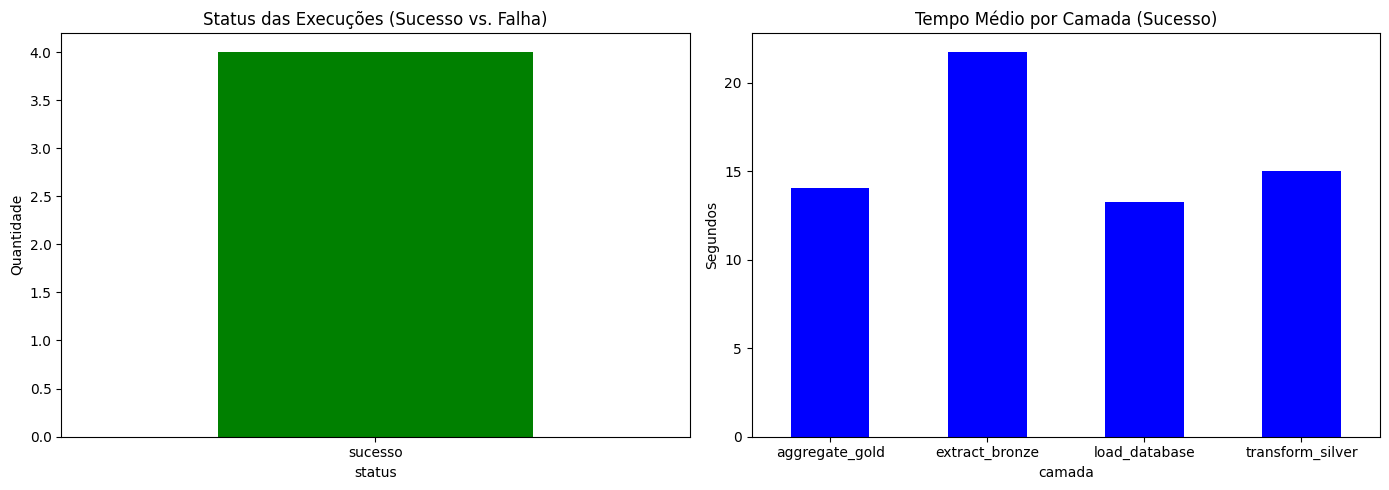


Gráficos salvos em: pipeline_monitoring_real.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from datetime import datetime

# ==========================================
# MONITORAMENTO DE EXECUÇÃO
# ==========================================

print("Conectando ao banco de dados do Airflow...")

DB_USER = "airflow"
DB_PASSWORD = "airflow"
DB_HOST = "localhost" 
DB_PORT = "5433"      
DB_NAME = "airflow"  

db_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

try:
    engine = create_engine(db_url)
except Exception as e:
    print(f"Erro ao conectar ao banco de dados: {e}")
    print("Verifique se o Docker está rodando e se a porta 5433 está exposta.")
    exit()
    
print("Conexão bem-sucedida!")

query = """
SELECT
    task_id AS camada,
    state AS status,
    EXTRACT(EPOCH FROM (end_date - start_date)) AS tempo_segundos,
    start_date AS data_execucao
FROM
    task_instance
WHERE
    dag_id = 'pipeline_etl_completo'
    AND state IS NOT NULL -- Ignora tarefas que ainda não rodaram
"""

print("Buscando dados das execuções...")
try:
    df_log = pd.read_sql(query, engine)
except Exception as e:
    print(f"Erro ao buscar dados: {e}")
    print("Verifique se a DAG 'pipeline_etl_completo' já executou alguma vez.")
    exit()

print("="*50)
print("MONITORAMENTO DO PIPELINE (DADOS REAIS)")
print("="*50)

if len(df_log) > 0:
    df_log['status'] = df_log['status'].replace({
        'success': 'sucesso',
        'failed': 'falha',
        'up_for_retry': 'falha'
    })
    
    df_analise = df_log[df_log['status'].isin(['sucesso', 'falha'])]

    if len(df_analise) > 0:
        taxa_sucesso = (df_analise['status'] == 'sucesso').sum() / len(df_analise) * 100
        print(f"\nTaxa de Sucesso: {taxa_sucesso:.2f}%")
    else:
        print("\nSem dados de 'sucesso' ou 'falha' para calcular taxa.")

    print("\nTempo Médio por Camada (em segundos):")

    df_sucesso = df_log[df_log['status'] == 'sucesso']
    if len(df_sucesso) > 0:
        print(df_sucesso.groupby('camada')['tempo_segundos'].mean().map('{:.2f}s'.format))
    else:
        print("Nenhuma tarefa completada com sucesso para calcular tempo médio.")

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    df_analise['status'].value_counts().plot(kind='bar', color=['green', 'red'])
    plt.title('Status das Execuções (Sucesso vs. Falha)')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=0)

    plt.subplot(1, 2, 2)
    if len(df_sucesso) > 0:
        df_sucesso.groupby('camada')['tempo_segundos'].mean().plot(kind='bar', color='blue')
        plt.title('Tempo Médio por Camada (Sucesso)')
        plt.ylabel('Segundos')
        plt.xticks(rotation=0)
    else:
        plt.title('Tempo Médio por Camada (Sem Dados)')

    plt.tight_layout()
    plt.savefig('pipeline_monitoring_real.png')
    plt.show() 

    print("\nGráficos salvos em: pipeline_monitoring_real.png")
    
else:
    print("\nNenhum dado de log encontrado para 'pipeline_etl_completo'.")